[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TarannumAhmedNowshin/Automated-Essay-Scoring/blob/main/llmmodels/falcon-1b.ipynb)


# Falcon 3 1B Instruct — Automated Essay Scoring (LLM)

Fine-tunes [`tiiuae/Falcon3-1B-Instruct`](https://huggingface.co/tiiuae/Falcon3-1B-Instruct)
as a **regression** model that predicts an essay score (0–10) from a
`Question` + `Answer` pair, trained on the **large** dataset (~1,408 graded scripts).

The decoder-only LLM is loaded in **4-bit** (`bitsandbytes`) to fit on a single
16 GB GPU. Its mean-pooled hidden states feed a small MLP regression head, trained
with a custom loop; the notebook reports **RMSE**, **MAE**, and **R²** per split.

**Before running:**
- Put the dataset in a local `data/` folder — see [data/README.md](../data/README.md).
- Set your Hugging Face token as an environment variable: `HF_TOKEN` (never hardcode it).
- Requires an NVIDIA GPU with CUDA for 4-bit quantization.


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.amp import autocast
from transformers import AutoTokenizer, TrainingArguments, AutoModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from bitsandbytes.optim import AdamW as BnbAdam
from transformers import BitsAndBytesConfig
from sklearn.model_selection import train_test_split

# Load your Hugging Face token from the environment.
# Set it before running, e.g. `export HF_TOKEN=...` (Linux/macOS) or `setx HF_TOKEN ...` (Windows).
# Never hardcode access tokens in notebooks that will be shared publicly.
hf_token = os.environ.get("HF_TOKEN")

# Set the device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the data (place the CSV in a local `data/` folder next to this notebook)
path = os.path.join("data", "essays_large.csv")
df = pd.read_csv(path)

# Drop rows where 'Answer' or 'Marks' is missing
df = df[['Question', 'Answer', 'Marks']].dropna(subset=['Answer', 'Marks'])

# Ensure 'Marks' column is numeric
df['Marks'] = pd.to_numeric(df['Marks'], errors='coerce')
df = df.dropna(subset=['Marks'])

# Normalize 'Marks' to the range [0, 10]
max_marks = 10
df['Marks'] = (df['Marks'] / df['Marks'].max()) * max_marks

# Combine 'Question' and 'Answer' into one column
df['combined_input'] = "Question: " + df['Question'].astype(str) + " Answer: " + df['Answer'].astype(str)

# Ensure inputs and scores are properly formatted
inputs = df['combined_input'].astype(str).tolist()
scores = df['Marks'].tolist()

# Debugging: Check a sample of inputs
print("Sample inputs:", inputs[:5])

# Tokenizer for Falcon-3-1B-Instruct
tokenizer = AutoTokenizer.from_pretrained("tiiuae/Falcon3-1B-Instruct", token=hf_token)
tokenizer.pad_token = tokenizer.eos_token  # Set pad token to eos token

# Train/test split
train_inputs, temp_inputs, train_scores, temp_scores = train_test_split(inputs, scores, test_size=0.2, random_state=42)
val_inputs, test_inputs, val_scores, test_scores = train_test_split(temp_inputs, temp_scores, test_size=0.5, random_state=42)

# Tokenizer with max_length
max_length = 256
train_encodings = tokenizer(train_inputs, padding='max_length', truncation=True, max_length=max_length, return_tensors="pt")
val_encodings = tokenizer(val_inputs, padding='max_length', truncation=True, max_length=max_length, return_tensors="pt")
test_encodings = tokenizer(test_inputs, padding='max_length', truncation=True, max_length=max_length, return_tensors="pt")

# Dataset class
class EssayDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

    def __len__(self):
        return len(self.labels)

# Prepare datasets
train_dataset = EssayDataset(train_encodings, train_scores)
val_dataset = EssayDataset(val_encodings, val_scores)
test_dataset = EssayDataset(test_encodings, test_scores)

# Quantization Configuration for Falcon-3-1B-Instruct
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

# Model setup for regression with Falcon-3-1B-Instruct
class FalconForRegression(torch.nn.Module):
    def __init__(self, model_name):
        super(FalconForRegression, self).__init__()
        self.falcon = AutoModel.from_pretrained(
            model_name,
            quantization_config=quantization_config,
            token=hf_token
        )
        self.regressor = torch.nn.Sequential(
            torch.nn.Linear(self.falcon.config.hidden_size, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.falcon(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = torch.mean(outputs.last_hidden_state, dim=1)  # CLS token
        logits = self.regressor(pooled_output).view(-1)

        if labels is not None:
            loss_fct = torch.nn.MSELoss()
            loss = loss_fct(logits, labels.view(-1))
            return loss, logits

        return logits

# Initialize the model
model = FalconForRegression("tiiuae/Falcon3-1B-Instruct")
model.to(device)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=4,  # Increased batch size for efficiency
    per_device_eval_batch_size=4,
    learning_rate=3e-5,  # Lower learning rate
    weight_decay=0.01,
    warmup_steps=500,  # Reduced warmup steps
    gradient_accumulation_steps=1,  # Simplified gradient accumulation
    lr_scheduler_type="linear",  # Changed scheduler to linear
    save_steps=500,
    save_total_limit=2,
    logging_dir='./logs',
    logging_steps=20,
    evaluation_strategy="steps",
    eval_steps=100,  # Evaluate every 100 steps
    logging_first_step=True,
    load_best_model_at_end=True,
    max_grad_norm=1.0,
)

# Custom Training Loop
optimizer = BnbAdam(model.parameters(), lr=training_args.learning_rate)
model.train()

for epoch in range(training_args.num_train_epochs):
    print(f"Epoch {epoch + 1}/{training_args.num_train_epochs}")
    for i, batch in enumerate(torch.utils.data.DataLoader(train_dataset, batch_size=training_args.per_device_train_batch_size)):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            loss, logits = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        if i % 10 == 0:
            print(f"Step {i}: Loss: {loss.item():.4f}")
            print(f"Logits (first 5): {logits[:5].detach().cpu().numpy()}")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

# Validation Loss Calculation
def calculate_validation_loss(dataset):
    model.eval()
    val_loss = 0
    val_steps = 0

    for batch in torch.utils.data.DataLoader(dataset, batch_size=training_args.per_device_eval_batch_size):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with torch.no_grad():
            with autocast(device_type='cuda'):
                loss, _ = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        
        val_loss += loss.item()
        val_steps += 1

    val_loss /= val_steps
    return val_loss

# Validation Loss
val_loss = calculate_validation_loss(val_dataset)
print(f"Validation Loss: {val_loss:.4f}")

# Evaluation Metrics Function
def evaluate(dataset):
    model.eval()
    preds = []
    labels = []

    for batch in torch.utils.data.DataLoader(dataset, batch_size=training_args.per_device_eval_batch_size):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['labels'].to(device)

        with torch.no_grad():
            with autocast(device_type='cuda'):
                logits = model(input_ids=input_ids, attention_mask=attention_mask)

        preds.extend(logits.cpu().numpy())
        labels.extend(labels_batch.cpu().numpy())

    mse = mean_squared_error(labels, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)

    return rmse, mae, r2, labels, preds

# Training Metrics
train_rmse, train_mae, train_r2, train_labels, train_preds = evaluate(train_dataset)
print(f"Training Metrics:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")
print(f"  R-squared: {train_r2:.4f}")

# Testing Metrics
test_rmse, test_mae, test_r2, test_labels, test_preds = evaluate(test_dataset)
print(f"Testing Metrics:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  R-squared: {test_r2:.4f}")


# Validation Metrics Calculation
val_rmse, val_mae, val_r2, val_labels, val_preds = evaluate(val_dataset)

# Print Validation Metrics
print(f"Validation Metrics:")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE: {val_mae:.4f}")
print(f"  R-squared: {val_r2:.4f}")


# True vs Predicted Comparison (Test Set)
comparison_df = pd.DataFrame({
    'True Scores': test_labels,
    'Predicted Scores': np.round(test_preds, 2)
})
print("True vs Predicted Scores (Test Set):")
print(comparison_df.head(10))


c:\Users\T2410207\Anaconda3\envs\falcon\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample inputs: ['Question: তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতায়  দেশাত্মবোধ ও অসাম্প্রদায়িকতার যে চিত্র রয়েছে, তা উদ্ধৃতিসহ নিজের ভাষায় বর্ণনা করো।\r Answer: কবি শামসুর রাহমান নাগরিক কবি হিসেবে পরিচিত। তিনি সংগ্রামী চেতনা ধারণ করে প্রকৃত অর্থেই নাগরিক কবি হয়ে উঠেন। তিনি সর্বদাই স্বাধীনতা এর পক্ষে সোচ্চার ছিলেন। স্বাধীনতার জন্য তিনি বেশ কয়েকটি রচনা করেছেন। ‘তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতাটি  রক্তক্ষয়ী মুক্তিযুদ্ধের প্রেক্ষাপটে রচিত।\r\n\r\n\r\n ‘তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতাটি দ্বারা স্বাধীনতা পাওয়ার আকাঙ্ক্ষাকে প্রকাশ করেছেন এবং স্বাধীনতার দৃশ্যচিত্র তুলে ধরা হয়েছে। কবিতাটি কবির শুধুমাত্র একদিনের চিন্তাচেতনার ফসল নয়, এটি বাংলাদেশের ভাষা আন্দোলন থেকে শুরু করে রক্তক্ষয়ী মুক্তিযুদ্ধের দীর্ঘস্থায়ী অপেক্ষার প্রতিফলন। এই কবিতাটি দ্বারা পাকিস্তানিদের জুলুম, নির্যাতন, বর্বরতার বাস্তব ঘটনাগুলো প্রতিফলিত হয়েছে। কবিতাটি কবির শ্রেষ্ঠ রচনার মধ্যে একটি, যেখানে কবির স্বাধীনতা পাওয়ার প্রতি আকুল নিবেদন ব্যক্ত করেছেন। \r\n\r\n\r\n ‘তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতায় দেশাত

`low_cpu_mem_usage` was None, now default to True since model is quantized.
c:\Users\T2410207\Anaconda3\envs\falcon\lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch 1/5
Step 0: Loss: 62.0292
Logits (first 5): [-0.098   -0.0956  -0.08026 -0.05945]
Step 10: Loss: 58.4561
Logits (first 5): [0.5073 0.4702 0.5137 0.467 ]
Step 20: Loss: 43.9005
Logits (first 5): [1.056 0.949 1.018 1.   ]
Step 30: Loss: 42.6597
Logits (first 5): [1.503 1.462 1.469 1.479]
Step 40: Loss: 36.9348
Logits (first 5): [1.917 1.961 1.914 1.888]
Step 50: Loss: 31.0559
Logits (first 5): [2.393 2.375 2.33  2.309]
Step 60: Loss: 30.2431
Logits (first 5): [2.773 2.7   2.87  2.748]
Step 70: Loss: 26.2791
Logits (first 5): [3.164 3.223 3.21  3.166]
Step 80: Loss: 20.7431
Logits (first 5): [3.656 3.773 3.682 3.693]
Step 90: Loss: 14.7455
Logits (first 5): [4.18  4.23  4.08  4.207]
Step 100: Loss: 11.3818
Logits (first 5): [4.67  4.758 4.703 4.645]
Step 110: Loss: 8.7317
Logits (first 5): [5.156 5.113 5.043 5.363]
Step 120: Loss: 5.2973
Logits (first 5): [5.695 5.75  5.65  5.504]
Step 130: Loss: 3.5669
Logits (first 5): [6.24  6.355 6.133 6.266]
Step 140: Loss: 2.2420
Logits (first

c:\Users\T2410207\Anaconda3\envs\falcon\lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [2]:
print("True vs Predicted Scores (Test Set):")
print(comparison_df.head(50))

True vs Predicted Scores (Test Set):
    True Scores  Predicted Scores
0          8.50          7.300781
1          7.00          7.339844
2          7.50          7.578125
3          7.00          7.710938
4          7.50          7.699219
5          5.00          7.621094
6          7.50          7.679688
7          7.50          8.023438
8          7.50          7.941406
9          8.00          7.800781
10         8.25          7.941406
11         5.00          7.460938
12         8.50          7.781250
13         7.50          7.601562
14         8.50          7.761719
15         7.50          7.781250
16         8.00          7.359375
17         7.50          7.828125
18         7.75          7.699219
19         7.50          7.730469
20         6.00          7.640625
21         8.00          8.000000
22         7.75          7.960938
23         8.75          7.980469
24         8.25          7.781250
25         8.00          8.007812
26         8.25          7.699219
27         

c:\Users\T2410207\Anaconda3\envs\falcon\lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


## Re-run with epoch-level loss tracking

Repeats the training loop while recording per-epoch train/validation loss, then
plots the loss curve.


Sample inputs: ['Question: তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতায়  দেশাত্মবোধ ও অসাম্প্রদায়িকতার যে চিত্র রয়েছে, তা উদ্ধৃতিসহ নিজের ভাষায় বর্ণনা করো।\r Answer: কবি শামসুর রাহমান নাগরিক কবি হিসেবে পরিচিত। তিনি সংগ্রামী চেতনা ধারণ করে প্রকৃত অর্থেই নাগরিক কবি হয়ে উঠেন। তিনি সর্বদাই স্বাধীনতা এর পক্ষে সোচ্চার ছিলেন। স্বাধীনতার জন্য তিনি বেশ কয়েকটি রচনা করেছেন। ‘তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতাটি  রক্তক্ষয়ী মুক্তিযুদ্ধের প্রেক্ষাপটে রচিত।\r\n\r\n\r\n ‘তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতাটি দ্বারা স্বাধীনতা পাওয়ার আকাঙ্ক্ষাকে প্রকাশ করেছেন এবং স্বাধীনতার দৃশ্যচিত্র তুলে ধরা হয়েছে। কবিতাটি কবির শুধুমাত্র একদিনের চিন্তাচেতনার ফসল নয়, এটি বাংলাদেশের ভাষা আন্দোলন থেকে শুরু করে রক্তক্ষয়ী মুক্তিযুদ্ধের দীর্ঘস্থায়ী অপেক্ষার প্রতিফলন। এই কবিতাটি দ্বারা পাকিস্তানিদের জুলুম, নির্যাতন, বর্বরতার বাস্তব ঘটনাগুলো প্রতিফলিত হয়েছে। কবিতাটি কবির শ্রেষ্ঠ রচনার মধ্যে একটি, যেখানে কবির স্বাধীনতা পাওয়ার প্রতি আকুল নিবেদন ব্যক্ত করেছেন। \r\n\r\n\r\n ‘তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতায় দেশাত

`low_cpu_mem_usage` was None, now default to True since model is quantized.
c:\Users\T2410207\Anaconda3\envs\falcon\lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch 1: Train Loss = 3.4629, Validation Loss = 0.5047
Epoch 2: Train Loss = 0.2305, Validation Loss = 0.4771
Epoch 3: Train Loss = 0.2218, Validation Loss = 0.4783
Epoch 4: Train Loss = 0.2160, Validation Loss = 0.4742
Epoch 5: Train Loss = 0.2120, Validation Loss = 0.4655


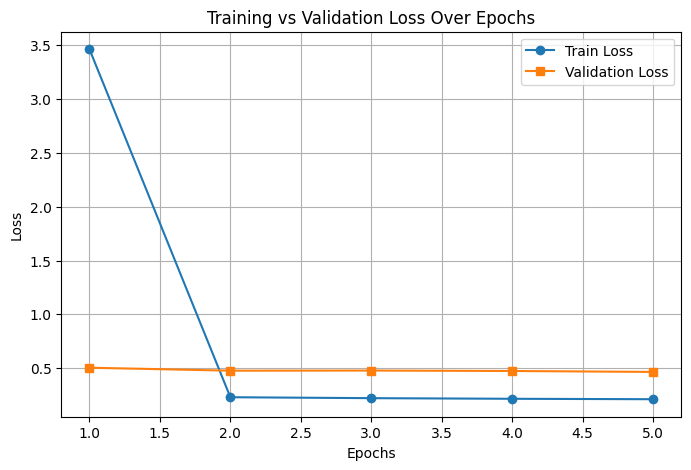

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.amp import autocast
from transformers import AutoTokenizer, TrainingArguments, AutoModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from bitsandbytes.optim import AdamW as BnbAdam
from transformers import BitsAndBytesConfig
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt  # Added for plotting

# Load your Hugging Face token from the environment.
# Set it before running, e.g. `export HF_TOKEN=...` (Linux/macOS) or `setx HF_TOKEN ...` (Windows).
# Never hardcode access tokens in notebooks that will be shared publicly.
hf_token = os.environ.get("HF_TOKEN")

# Set the device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the data (place the CSV in a local `data/` folder next to this notebook)
path = os.path.join("data", "essays_large.csv")
df = pd.read_csv(path)

# Drop rows where 'Answer' or 'Marks' is missing
df = df[['Question', 'Answer', 'Marks']].dropna(subset=['Answer', 'Marks'])

# Ensure 'Marks' column is numeric
df['Marks'] = pd.to_numeric(df['Marks'], errors='coerce')
df = df.dropna(subset=['Marks'])

# Normalize 'Marks' to the range [0, 10]
max_marks = 10
df['Marks'] = (df['Marks'] / df['Marks'].max()) * max_marks

# Combine 'Question' and 'Answer' into one column
df['combined_input'] = "Question: " + df['Question'].astype(str) + " Answer: " + df['Answer'].astype(str)

# Ensure inputs and scores are properly formatted
inputs = df['combined_input'].astype(str).tolist()
scores = df['Marks'].tolist()

# Debugging: Check a sample of inputs
print("Sample inputs:", inputs[:5])

# Tokenizer for Falcon-3-1B-Instruct
tokenizer = AutoTokenizer.from_pretrained("tiiuae/Falcon3-1B-Instruct", token=hf_token)
tokenizer.pad_token = tokenizer.eos_token  # Set pad token to eos token

# Train/test split
train_inputs, temp_inputs, train_scores, temp_scores = train_test_split(inputs, scores, test_size=0.2, random_state=42)
val_inputs, test_inputs, val_scores, test_scores = train_test_split(temp_inputs, temp_scores, test_size=0.5, random_state=42)

# Tokenizer with max_length
max_length = 256
train_encodings = tokenizer(train_inputs, padding='max_length', truncation=True, max_length=max_length, return_tensors="pt")
val_encodings = tokenizer(val_inputs, padding='max_length', truncation=True, max_length=max_length, return_tensors="pt")
test_encodings = tokenizer(test_inputs, padding='max_length', truncation=True, max_length=max_length, return_tensors="pt")

# Dataset class
class EssayDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

    def __len__(self):
        return len(self.labels)

# Prepare datasets
train_dataset = EssayDataset(train_encodings, train_scores)
val_dataset = EssayDataset(val_encodings, val_scores)
test_dataset = EssayDataset(test_encodings, test_scores)

# Quantization Configuration for Falcon-3-1B-Instruct
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

# Model setup for regression with Falcon-3-1B-Instruct
class FalconForRegression(torch.nn.Module):
    def __init__(self, model_name):
        super(FalconForRegression, self).__init__()
        self.falcon = AutoModel.from_pretrained(
            model_name,
            quantization_config=quantization_config,
            token=hf_token
        )
        self.regressor = torch.nn.Sequential(
            torch.nn.Linear(self.falcon.config.hidden_size, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.falcon(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = torch.mean(outputs.last_hidden_state, dim=1)  # CLS token
        logits = self.regressor(pooled_output).view(-1)

        if labels is not None:
            loss_fct = torch.nn.MSELoss()
            loss = loss_fct(logits, labels.view(-1))
            return loss, logits

        return logits

# Initialize the model
model = FalconForRegression("tiiuae/Falcon3-1B-Instruct")
model.to(device)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=500,
    gradient_accumulation_steps=1,
    lr_scheduler_type="linear",
    save_steps=500,
    save_total_limit=2,
    logging_dir='./logs',
    logging_steps=20,
    evaluation_strategy="steps",
    eval_steps=100,
    logging_first_step=True,
    load_best_model_at_end=True,
    max_grad_norm=1.0,
)

# Custom Training Loop with Training vs Validation Loss Tracking
optimizer = BnbAdam(model.parameters(), lr=training_args.learning_rate)
train_losses = []
val_losses = []

for epoch in range(training_args.num_train_epochs):
    model.train()
    train_loss = 0

    for batch in torch.utils.data.DataLoader(train_dataset, batch_size=training_args.per_device_train_batch_size):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            loss, _ = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        train_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    # Average train loss for this epoch
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    # Calculate validation loss
    val_loss = calculate_validation_loss(val_dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")

# Plot Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, training_args.num_train_epochs + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, training_args.num_train_epochs + 1), val_losses, label="Validation Loss", marker="s")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


## Visualizing predictions and errors

- **True vs. predicted marks** — points on the dashed diagonal are perfect predictions.
- **True marks vs. prediction error** — absolute error across the score range.


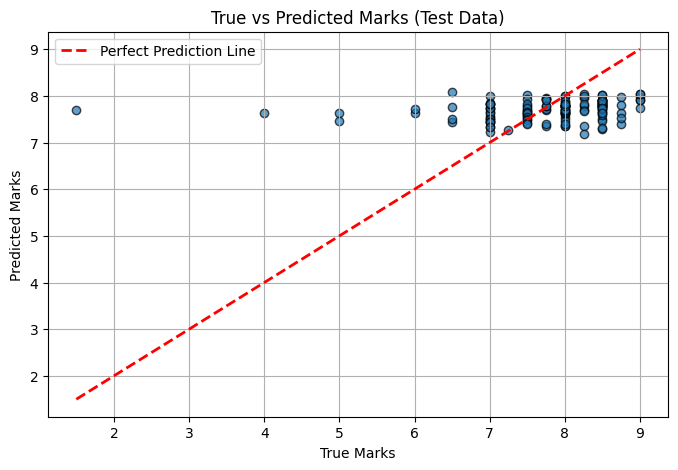

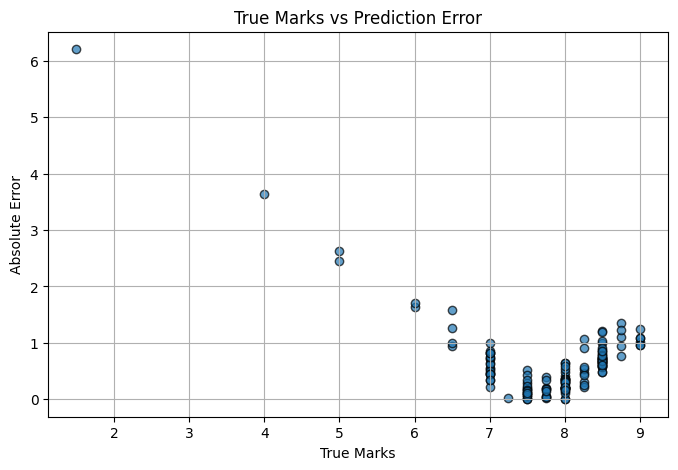

In [5]:
import matplotlib.pyplot as plt

# Convert predictions to numpy array for better handling
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

# 1. True vs Predicted Marks (Test Data)
plt.figure(figsize=(8, 5))
plt.scatter(test_labels, test_preds, alpha=0.7, edgecolors="k")
plt.plot([min(test_labels), max(test_labels)], [min(test_labels), max(test_labels)], color="red", linestyle="--", linewidth=2, label="Perfect Prediction Line")
plt.xlabel("True Marks")
plt.ylabel("Predicted Marks")
plt.title("True vs Predicted Marks (Test Data)")
plt.legend()
plt.grid(True)
plt.show()

# 2. True Marks vs Error (Absolute Error)
errors = np.abs(test_labels - test_preds)

plt.figure(figsize=(8, 5))
plt.scatter(test_labels, errors, alpha=0.7, edgecolors="k")
plt.xlabel("True Marks")
plt.ylabel("Absolute Error")
plt.title("True Marks vs Prediction Error")
plt.grid(True)
plt.show()
